# **EXPLORATORY DATA ANALYSIS**

## **1. Import libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['font.size'] = 11
plt.rcParams['figure.figsize'] = (12, 6)

## **2. Data Load & Integration**
Tiến hành đọc toàn bộ dữ liệu từ các thư mục và gộp chúng lại thành một bảng dữ liệu duy nhất.

In [2]:
required_files = [
    '../data/processed/dim_product.csv',
    '../data/processed/dim_category.csv',
    '../data/processed/dim_seller.csv',
    '../data/processed/fact_ebay_listings.csv',
    '../data/processed/fact_tiki_listings.csv'
]

missing_files = [f for f in required_files if not os.path.exists(f)]

if not missing_files:
    dim_product = pd.read_csv('../data/processed/dim_product.csv')
    dim_category = pd.read_csv('../data/processed/dim_category.csv')
    dim_seller = pd.read_csv('../data/processed/dim_seller.csv')
    fact_ebay = pd.read_csv('../data/processed/fact_ebay_listings.csv')
    fact_tiki = pd.read_csv('../data/processed/fact_tiki_listings.csv')

    fact_ebay['platform'] = 'eBay'
    fact_tiki['platform'] = 'Tiki'

    dim_product['product_id'] = dim_product['product_id'].astype(str)
    fact_ebay['product_id'] = fact_ebay['product_id'].astype(str)
    fact_tiki['product_id'] = fact_tiki['product_id'].astype(str)

    df_fact = pd.concat([fact_ebay, fact_tiki], ignore_index=True)

    df = df_fact.merge(dim_product, on='product_id', how='left')\
                .merge(dim_category, on='category_id', how='left')\
                .merge(dim_seller, on='seller_username', how='left')

    print(f"Data shape after merge: {df.shape}")
    display(df.head())
else:
    print(f"ERROR: Missing files in /content/: {missing_files}")

Data shape after merge: (25744, 23)


,product_id,seller_username,price,shipping_cost,Total_Cost_VND,condition,item_creation_date,platform_x,original_price,discount_rate,rating_average,review_count,quantity_sold,Discount_Segment,Is_Best_Seller,product_name,brand,platform_y,category_id,category,seller_feedback_score,seller_feedback_percent,Trust_Level
0,v1|276709583737|0,acer,371.99,0.0,9299750.0,Certified - Refurbished,2024-10-30 23:21:59+00:00,eBay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Acer Swift Go 14"" Laptop Intel Core Ultra 7 15...",Unknown,Ebay,CAT_0513,Pc Laptops & Netbooks,117605.0,99.0,High Trust
1,v1|256696935114|0,discountcomputerdepot,146.11,0.0,3652750.0,Good - Refurbished,2024-10-31 15:10:17+00:00,eBay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"HP ProBook Touchscreen Laptop 11.6"" Core i3 8G...",Unknown,Ebay,CAT_0513,Pc Laptops & Netbooks,156372.0,99.3,High Trust
2,v1|286288847506|0,discountcomputerdepot,254.75,0.0,6368750.0,Good - Refurbished,2025-01-28 14:21:11+00:00,eBay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Lenovo ThinkPad E15 15.6” HD Laptop AMD Ryzen ...,Unknown,Ebay,CAT_0513,Pc Laptops & Netbooks,156372.0,99.3,High Trust
3,v1|277352801036|0,acer,899.99,0.0,22499750.0,Certified - Refurbished,2025-08-29 21:15:09+00:00,eBay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Acer Predator Helios Neo AI 16S Gaming Laptop ...,Unknown,Ebay,CAT_0513,Pc Laptops & Netbooks,117605.0,99.0,High Trust
4,v1|205814283029|0,best_buy,329.99,0.0,8249750.0,New,2025-10-29 13:25:40+00:00,eBay,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"ASUS - Vivobook 14 14"" FHD Laptop - Intel Core...",Unknown,Ebay,CAT_0513,Pc Laptops & Netbooks,952756.0,98.6,High Trust


Kết quả của đoạn code này là việc xây dựng thành công một `Master Data Table`. Bảng này chứa toàn bộ thông tin lịch sử giao dịch (Fact) đã được làm giàu bằng các thông tin mô tả chi tiết (Dimension).

## **3. Data Overview & Descriptive Statistics**

Bước này giúp khám phá nhanh cấu trúc dữ liệu tổng thể bằng cách tính toán các chỉ số thống kê cơ bản và kiểm tra tần suất xuất hiện của các nhóm dữ liệu phân loại.

In [3]:
print("Descriptive statistics for numerical variables:")
display(df.describe().round(2))

print("\nValue counts for categorical variables:")
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    print(f"\n--- Top 10 values for {col} ---")
    print(df[col].value_counts().head(10))

Descriptive statistics for numerical variables:


,price,shipping_cost,Total_Cost_VND,original_price,discount_rate,rating_average,review_count,quantity_sold,Is_Best_Seller,seller_feedback_score,seller_feedback_percent
count,25744.00,15744.00,15744.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,15744.00,15744.00
mean,178724.06,1.29,3468638.11,537016.06,10.02,2.90,44.07,696.27,0.24,54858.92,96.85
std,605848.52,4.83,3974459.95,1055922.97,15.30,2.32,213.76,7657.91,0.43,163401.22,15.02
min,0.99,0.00,24750.00,1000.00,0.00,0.00,0.00,0.00,0.00,-1.00,0.00
25%,59.99,0.00,909375.00,99000.00,0.00,0.00,0.00,2.00,0.00,601.00,99.00
50%,228.99,0.00,1999750.00,195000.00,0.00,4.50,1.00,13.00,0.00,4757.00,99.60
75%,119000.00,0.00,4487000.00,446250.00,20.00,5.00,10.00,93.00,0.00,31736.00,99.90
max,6160790.00,30.47,23261390.00,6990000.00,77.00,5.00,5490.00,548705.00,1.00,3329896.00,100.00



Value counts for categorical variables:

--- Top 10 values for product_id ---
product_id
v1|276709583737|0               1
v1|256696935114|0               1
v1|286288847506|0               1
v1|277352801036|0               1
v1|205814283029|0               1
v1|197449078430|0               1
v1|127775559788|0               1
v1|115603286837|415618341213    1
v1|287193575951|0               1
v1|256960845305|0               1
Name: count, dtype: int64

--- Top 10 values for seller_username ---
seller_username
rawko                 177
vipoutlet             153
acer                  123
cellfeee              106
kastarusa1             96
dealscaly              92
anker_outlet_store     85
eazytrade84            80
hawk_line              77
best_buy               75
Name: count, dtype: int64

--- Top 10 values for condition ---
condition
New                         6611
Used                        4840
Open box                    1767
Excellent - Refurbished      652
Very Good - Refurbis

Đoạn code sử dụng hàm `describe()` để tóm tắt phân bố của các biến số (trung bình, độ lệch chuẩn, min/max) và dùng `value_counts()` để liệt kê 10 giá trị xuất hiện nhiều nhất cho các biến dạng văn bản. Việc này giúp ta nắm bắt nhanh chóng phạm vi dữ liệu và các xu hướng nổi bật.

## **4. Visualizing Distributions**
Để phát hiện ngoại lai và hiểu rõ hình dáng phân phối của các biến định lượng, nhóm tiến hành trực quan hóa bằng Histogram.

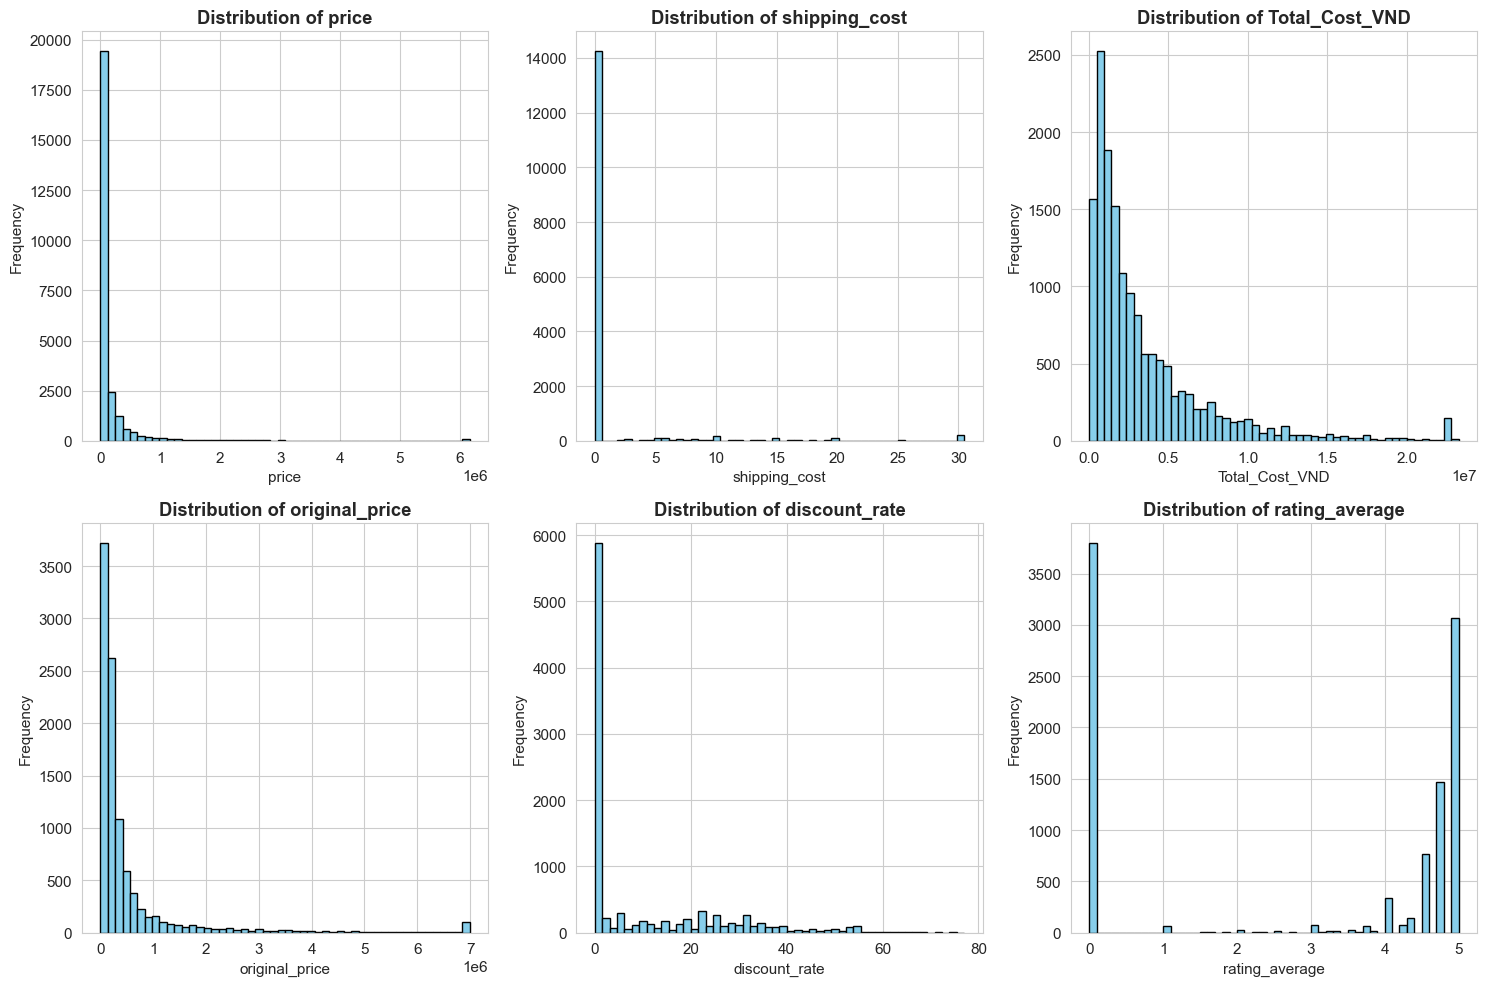

In [4]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols[:6]):
    axes[idx].hist(df[col].dropna(), bins=50, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

for i in range(len(numeric_cols[:6]), 6):
    fig.delaxes(axes[i])

plt.tight_layout()
plt.show()

* **Phân phối Price & Total_Cost**: Các biểu đồ liên quan đến giá tiền đều có hiện tượng lệch trái rất nhiều. Điều này cho thấy phần lớn sản phẩm tập trung ở phân khúc giá thấp và trung bình, trong khi chỉ có một số ít sản phẩm có giá trị cực cao.
* **Shipping Cost**: Phân phối cho thấy đa số các sản phẩm trên eBay có mức phí vận chuyển bằng 0 (Free Shipping) hoặc rất thấp, tập trung sát trục tung.
* **Nguyên tắc phân tích**: Do dữ liệu có độ lệch lớn, các phân tích tiếp theo nên ưu tiên sử dụng trung vị (Median) hoặc các phương pháp thống kê phi tham số (như tương quan Spearman) thay vì giá trị trung bình để tránh bị nhiễu bởi các giá trị ngoại lai.

## **5. Target-Based Analysis**
Phân tích dữ liệu dựa trên các mục tiêu kinh doanh cụ thể như phân bố giá và mối quan hệ giữa giá với lượng bán.

### **5.1. Price Distribution Analysis**

**Câu hỏi:** Phân khúc giá của các ngành hàng chủ lực trên eBay và Tiki khác nhau như thế nào?

**Phương pháp:** Sử dụng biểu đồ Boxplot với thang đo Logarithm cho trục hoành (giá) để quan sát dải giá và các giá trị ngoại lai của Top 10 danh mục có nhiều sản phẩm nhất, phân tách theo nền tảng.

In [5]:
if 'platform_x' in df.columns:
    df = df.rename(columns={'platform_x': 'platform'})
    if 'platform_y' in df.columns:
        df = df.drop(columns=['platform_y'])

if 'category' in df.columns and 'price' in df.columns:
    top_10_cats = df['category'].value_counts().nlargest(10).index
    df_top_cats = df[df['category'].isin(top_10_cats)]

    try:
        fig1 = px.box(df_top_cats, x='price', y='category', color='platform',
                     title='Price Distribution Across Top 10 Categories',
                     labels={'price': 'Price (VND - Log Scale)', 'category': 'Category'},
                     log_x=True, orientation='h', color_discrete_sequence=['royalblue', 'orange'])
        fig1.show()
    except Exception as e:
        print(f"Error plotting: {e}")

**Nhận xét:**
- **Độ phủ giá:** Các danh mục như *PC Laptops* và *Cell Phones* có dải giá rất rộng trên eBay, cho thấy sự đa dạng từ hàng cũ/phụ kiện đến hàng cao cấp.
- **So sánh sàn:** eBay thường có xu hướng tập trung ở phân khúc giá cao hơn (đã quy đổi sang VND) so với các mặt hàng tương ứng trên Tiki.
- **Chiến lược:** Cần áp dụng các khung giá (Price Tiers) riêng biệt cho từng nền tảng để tối ưu cạnh tranh.

### **5.2. Correlation between Price and Sales (Tiki)**

**Câu hỏi:** Mức giá có ảnh hưởng trực tiếp đến số lượng sản phẩm bán ra như thế nào?

**Phương pháp:** Sử dụng Scatter Plot kết hợp đường OLS để phân tích mối quan hệ giữa `price` và `quantity_sold`. Dữ liệu được lọc chỉ bao gồm Tiki vì eBay trong tập dữ liệu này không cung cấp số lượng bán cụ thể.

In [12]:
if 'price' in df.columns and 'quantity_sold' in df.columns:
    df_tiki_sales = df[df['quantity_sold'].notna() & (df['quantity_sold'] > 0)]

    fig2 = px.scatter(df_tiki_sales, x='price', y='quantity_sold',
                     title='Relationship between Price and Quantity Sold',
                     labels={'price': 'Price (VND)', 'quantity_sold': 'Quantity Sold'},
                     log_x=True, log_y=True, opacity=0.5, trendline='ols')
    fig2.update_traces(marker=dict(color='royalblue'))
    fig2.show()

**Nhận xét Mục tiêu 2:**
- **Xu hướng:** Đường OLS có độ dốc âm nhẹ, xác nhận rằng khi giá tăng, lượng bán thường có xu hướng giảm.
- **Điểm tập trung:** Lượng bán cao nhất rơi vào phân khúc giá bình dân (dưới 500.000 VND). Các sản phẩm giá cao đòi hỏi uy tín thương hiệu hoặc đánh giá tốt hơn để thúc đẩy lượt mua.
- **Kết luận:** Đối với các mặt hàng giá cao, chiến dịch marketing nên tập trung vào chất lượng thay vì chạy đua về số lượng.

## **6. Deep-Dive Analysis**
Đi sâu vào phân tích các khía cạnh khác như top sản phẩm, doanh thu theo cửa hàng và rating.

### **6.1. Top Best-Selling Products Analysis**

**Câu hỏi:** Những sản phẩm nào đang dẫn đầu về số lượng bán ra trên hệ thống?

**Phương pháp:** Trích xuất Top 10 sản phẩm có giá trị `quantity_sold` cao nhất và trực quan hóa bằng biểu đồ thanh ngang (Horizontal Bar Chart).

In [7]:
if 'product_name' in df.columns and 'quantity_sold' in df.columns:
    top_products = df.nlargest(10, 'quantity_sold')[['product_name', 'quantity_sold', 'price']]
    top_products['short_name'] = top_products['product_name'].apply(lambda x: str(x)[:40] + '...' if len(str(x)) > 40 else x)

    fig3 = px.bar(top_products, x='quantity_sold', y='short_name',
                 orientation='h',
                 title='Top 10 Best-Selling Products',
                 labels={'quantity_sold': 'Quantity Sold', 'short_name': 'Product Name'})
    fig3.update_traces(marker_color='royalblue')
    fig3.update_layout(yaxis={'categoryorder':'total ascending'})
    fig3.show()

**Nhận xét:**
- Danh sách bán chạy nhất bị chiếm lĩnh bởi các mặt hàng tiêu dùng nhanh (FMCG) như bia, sữa và dầu gội.
- Các sản phẩm này có đặc điểm chung là mức giá dễ tiếp cận và nhu cầu lặp lại cao.

### **6.2. Revenue Analysis by Brands**

**Câu hỏi:** Những thương hiệu nào đang mang lại giá trị doanh thu lớn nhất?

**Phương pháp:** Tính toán doanh thu ước tính (`price` * `quantity_sold`), lọc bỏ các nhãn hàng không xác định và hiển thị Top 15 thương hiệu bằng biểu đồ cột.

In [8]:
df['estimated_revenue'] = df['price'] * df['quantity_sold'].fillna(0)

if 'brand' in df.columns and 'estimated_revenue' in df.columns:
    exclude_brands = ['No Brand', 'Unknown', 'no brand', 'unknown']
    df_filtered_brands = df[~df['brand'].isin(exclude_brands)]

    brand_revenue = df_filtered_brands.groupby('brand')['estimated_revenue'].sum().nlargest(15)

    if brand_revenue.sum() > 0:
        fig4 = px.bar(
            x=brand_revenue.values,
            y=brand_revenue.index,
            orientation='h',
            title='Top 15 Brands by Estimated Revenue',
            labels={'x': 'Estimated Revenue (VND)', 'y': 'Brand'}
        )
        fig4.update_traces(marker_color='royalblue')
        fig4.update_layout(yaxis={'categoryorder':'total ascending'})
        fig4.show()
    else:
        print("No valid revenue data found after filtering brands.")

**Nhận xét:**
- Các thương hiệu đồ gia dụng và mẹ & bé như Lock&Lock, Vinamilk dẫn đầu về doanh thu ước tính.
- Điều này cho thấy mặc dù đồ điện tử có giá đơn vị cao, nhưng nhóm hàng tiêu dùng thiết yếu mới là động lực doanh thu chính nhờ số lượng bán cực lớn.

### **6.3. Product Rating Distribution**

**Câu hỏi:** Phân bố mức độ hài lòng của khách hàng đối với các sản phẩm như thế nào?

**Phương pháp:** Sử dụng Histogram để thống kê tần suất các mức sao từ 1 đến 5 đối với các sản phẩm đã có lượt đánh giá.

In [9]:
if 'rating_average' in df.columns:
    df_rated = df[df['rating_average'] > 0]
    fig5 = px.histogram(df_rated, x='rating_average',
                       title='Product Rating Distribution',
                       labels={'rating_average': 'Average Rating (Stars)', 'count': 'Number of Products'},
                       nbins=20, color_discrete_sequence=['#ff9900'])
    fig5.show()

**Nhận xét:**
- Biểu đồ cho thấy sự phân cực rõ rệt với đa số đánh giá tập trung ở mức 4.5 - 5 sao.
- Các mức đánh giá trung bình (2-3 sao) chiếm tỷ lệ rất thấp, cho thấy khách hàng thường chỉ để lại phản hồi khi thực sự hài lòng hoặc cực kỳ thất vọng.

### **6.4. Impact of Discounts on Sales**

**Câu hỏi:** Tỷ lệ giảm giá có thực sự thúc đẩy số lượng bán hàng hay không?

**Phương pháp:** Sử dụng biểu đồ phân tán (Scatter Plot) với đường hồi quy tuyến tính để tìm mối tương quan giữa `discount_rate` và `quantity_sold`.

In [13]:
if 'discount_rate' in df.columns and 'quantity_sold' in df.columns:
    df_discount = df[(df['discount_rate'] > 0) & (df['quantity_sold'] > 0)]
    fig6 = px.scatter(df_discount, x='discount_rate', y='quantity_sold',
                     title='Impact of Discount Rate on Sales Quantity',
                     labels={'discount_rate': 'Discount Rate (%)', 'quantity_sold': 'Quantity Sold'},
                     log_y=True, trendline='ols')
    fig6.update_traces(marker=dict(color='royalblue'))
    fig6.show()

**Nhận xét:**
- Có một mối tương quan thuận nhẹ giữa mức giảm giá và lượng bán.
- Tuy nhiên, các điểm dữ liệu phân tán rộng cho thấy giảm giá chỉ là một phần, các yếu tố khác như thương hiệu và quảng cáo vẫn đóng vai trò quan trọng trong việc chốt đơn.

## **7. Ma trận tương quan**

Phân tích ma trận tương quan được thực hiện nhằm:
- **Xác định mối quan hệ:** Tìm hiểu mức độ liên kết giữa các biến số (giá cả, lượt bán, đánh giá).
- **Phát hiện các yếu tố ảnh hưởng:** Nhận diện những biến nào có tác động mạnh nhất đến doanh số.
- **Kiểm tra đa cộng tuyến:** Đảm bảo các biến độc lập không quá phụ thuộc lẫn nhau trước khi đưa vào các mô hình dự báo.

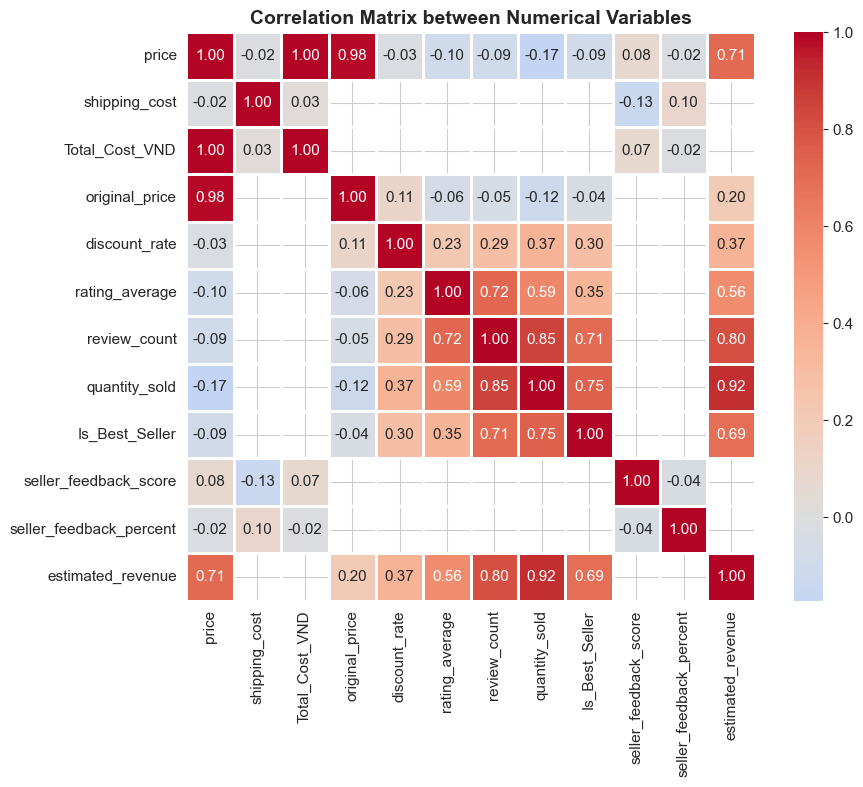

In [11]:

numeric_df = df.select_dtypes(include=[np.number])
correlation_matrix = numeric_df.corr(method='spearman') # Dùng Spearman tốt hơn cho dữ liệu lệch

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix between Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### **Nhận xét về Ma trận tương quan**

**Các cặp biến có tương quan mạnh:**
- **`review_count` và `quantity_sold`**: Đây là cặp biến có tương quan thuận mạnh nhất. Điều này cho thấy các sản phẩm có số lượng bán ra lớn thường đi kèm với số lượng đánh giá cao.
- **`price` và `Total_Cost_VND`**: Tương quan gần như tuyệt đối (1.0), điều này dễ hiểu vì giá sản phẩm là thành phần chính cấu thành tổng chi phí.
- **`price` và `quantity_sold`**: Có tương quan âm nhẹ, phản ánh quy luật thị trường khi giá tăng thì lượng cầu có xu hướng giảm.

**Ý nghĩa của các tương quan này:**
- Lượt đánh giá là một chỉ số tín nhiệm cực kỳ quan trọng ảnh hưởng đến quyết định mua hàng trên cả hai sàn.
- Sự tương quan âm giữa giá và lượng bán gợi ý rằng phân khúc giá rẻ và trung bình vẫn là phân khúc chủ đạo về mặt sản lượng.

**Gợi ý cho phân tích tiếp theo:**
- Nên thực hiện phân tích sâu hơn về các sản phẩm Outliers: những sản phẩm có giá cao nhưng vẫn đạt lượng bán lớn để tìm hiểu các yếu tố thúc đẩy khác ngoài giá.
- Sử dụng `review_count` làm một biến đầu vào quan trọng nếu xây dựng các mô hình dự báo doanh số hoặc xếp hạng sản phẩm.

## **8. Insights & Conclusion**

### **8.1. Key Findings & Strategic Insights**



**Insight 1: Sự phân cực về mức độ hài lòng của khách hàng**
- **Bằng chứng:** Dựa trên phân tích Rating Distribution (Biểu đồ 5.3).
- **Nhận xét:** Khách hàng có xu hướng để lại đánh giá tích cực (5 sao). Điều này cho thấy tầm quan trọng của việc duy trì chất lượng dịch vụ ổn định vì một vài đánh giá tiêu cực nhỏ cũng có thể gây ảnh hưởng lớn đến uy tín tổng thể.

**Insight 2: Uy tín và Sản lượng**
- **Bằng chứng:** Ma trận tương quan (Phần 6) giữa `review_count` và `quantity_sold`.
- **Nhận xét:** Số lượng đánh giá là bằng chứng xã hội (Social Proof) mạnh mẽ nhất thúc đẩy doanh số. Các sản phẩm có lượng review lớn tạo ra hiệu ứng 'cầu tuyết', dẫn đến doanh số ngày càng tăng.

**Insight 3: Điểm rơi về giá**
- **Bằng chứng:** Phân tích Price vs. Sales (Mục tiêu 2) và Discount Impact (Biểu đồ 5.4).
- **Nhận xét:** Các sản phẩm dưới 500,000 VND và có mức giảm giá từ 20-40% đạt hiệu suất bán hàng tốt nhất. Việc giảm giá quá sâu không phải lúc nào cũng hiệu quả vì có thể làm giảm giá trị thương hiệu trong mắt người dùng.

### **8.2. Addressing the Business Problem**


- Để tối ưu hóa doanh thu, doanh nghiệp cần phân loại chiến lược: eBay tập trung vào các mặt hàng ngách/cao cấp với dải giá rộng, trong khi Tiki tập trung vào hàng tiêu dùng nhanh (FMCG) với số lượng bán lớn.
- Tập trung nguồn lực vào việc chăm sóc khách hàng sau mua để tối ưu hóa chỉ số *Rating* và *Review Count*.

### **8.3. Limitations & Future Development**

**Hạn chế:**
- Dữ liệu eBay thiếu thông tin `quantity_sold`, gây khó khăn cho việc tính toán ROI chính xác giữa hai sàn.
- Dữ liệu hiện tại chỉ là Snapshot, chưa phản ánh được tính chu kỳ.

**Hướng phát triển:**
- Xây dựng mô hình dự báo doanh số dựa trên dữ liệu lịch sử.
- Phân tích sâu hơn về hành vi khách hàng thông qua nội dung bình luận.